<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/04_pytorch_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# importing the pytorch libraries  and devicd agnostic code
import torch
from torch import nn

torch.__version__

'2.11.0+cpu'

In [9]:
# set up device code
device="cude" if torch.cuda.is_available() else "cpu"
device

'cpu'

### get the dataset

our dataset is subset of the food101 dataset
food101 start 101 diff classs of food and 1000 images per class (750 training and 250 test)

our data set with class 3 and only 10 per of the images (75 training ,25 testing)
why do this
when start ml project its impr to start with small dataset and tehn increase the scale when necessary
the whole point is to fast

In [10]:
import requests
import zipfile
from pathlib import Path

# set up  to data

data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"

#if image folder does not exist ,download it and prepare it
if image_path.is_dir():
  print(f"{image_path} directory already exist")
else:
  print(f"{image_path} directory not exist creating it ")
  image_path.mkdir(parents=True,exist_ok=True)
# download the data
with open(data_path/"pizza_steak_sushi.zip","wb") as f:
  request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("downlaoding the data in to raw folder")
  f.write(request.content)

# unzip the data
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
  print("unzipping the data")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exist
downlaoding the data in to raw folder
unzipping the data


Becoming one with the data(data preparation and data exploration)

In [11]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [12]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.


In [13]:
# set up train and testing paths
train_dir=image_path/"train"
test_dir=image_path/"test"

visualizizing and image

let write some code :

* get all of the images paths
* pick a random image path using the python random.choice()
* get the image class name pathlib .path.parent.stem
* since we working with the images let open with the python pillow
* well then show the image and print  the meta data

In [15]:
!pip install PTL

data/pizza_steak_sushi/train/sushi/748830.jpg
random image path:data/pizza_steak_sushi/train/sushi/748830.jpg
image class:sushi
image height:287
image width:512


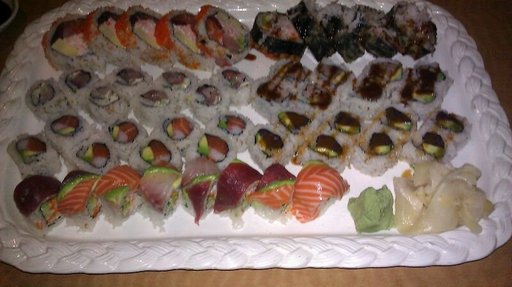

In [48]:
import random
from PIL import Image

# set  the random
random.seed(42)

# get all images paths
image_path_list=list(image_path.glob("*/*/*.jpg"))
#print(image_path)
# get the random image from the image path
random_image=random.choice(image_path_list)
print(random_image)
# get eh image class from the path name (the image class is the  name of the directory where the image  stored )
image_class=random_image.parent.stem
#image_class

# open image
img=Image.open(random_image)
img
# print meta data
print(f"random image path:{random_image}")
print(f"image class:{image_class}")
print(f"image height:{img.height}")
print(f"image width:{img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(286.5), np.float64(-0.5))

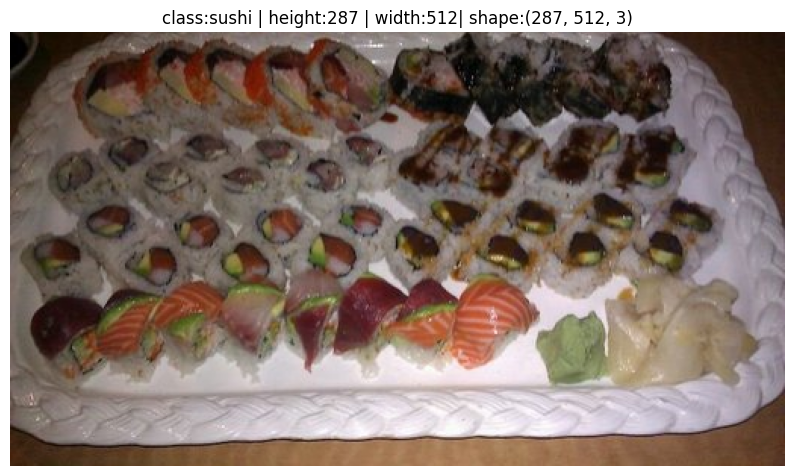

In [50]:
# dot he above with the matplot lib library
import numpy as np
import matplotlib.pyplot as plt

# turn the image in to array
img_arr=np.asarray(img)

#plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_arr)
plt.title(f"class:{image_class} | height:{img.height} | width:{img.width}| shape:{img_arr.shape}")
plt.axis(False)

array([[[10,  6,  3],
        [17, 13, 10],
        [29, 24, 20],
        ...,
        [33, 16,  9],
        [34, 17, 10],
        [34, 17, 10]],

       [[ 4,  0,  0],
        [10,  6,  3],
        [19, 14, 11],
        ...,
        [36, 19, 12],
        [37, 20, 13],
        [37, 20, 13]],

       [[ 3,  0,  0],
        [ 3,  0,  0],
        [ 8,  3,  0],
        ...,
        [37, 20, 13],
        [37, 20, 13],
        [37, 20, 13]],

       ...,

       [[69, 38, 18],
        [67, 39, 18],
        [70, 39, 19],
        ...,
        [87, 55, 40],
        [85, 53, 38],
        [83, 51, 36]],

       [[69, 41, 20],
        [68, 40, 19],
        [67, 39, 18],
        ...,
        [83, 51, 36],
        [83, 51, 36],
        [83, 51, 36]],

       [[68, 41, 22],
        [66, 39, 20],
        [64, 37, 18],
        ...,
        [78, 46, 31],
        [80, 48, 35],
        [82, 50, 37]]], dtype=uint8)
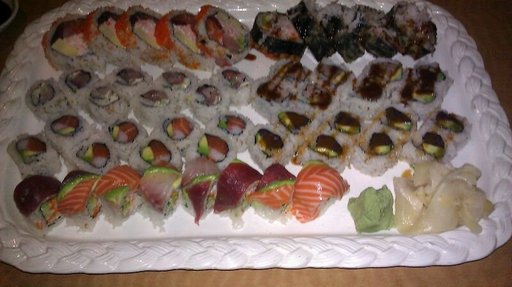

In [51]:
img_arr

Transforming data

before we use our image data with pytorch:
* turn your target data in to tensor ( inour case numerical representation of pur images)
* turn it in to  torch.utlis.data.Dataset and subsequently a
torch.utlis.data.DataLoader well call these dataset and the DataLoader for short

In [53]:
import torch
from torch.utils.data import dataloader
from torchvision import datasets,transforms

Tranforming data with torchvision.transforms

In [54]:
# write a transform for image

data_transform=transforms.Compose(
    [
        # resize image to 64*63
        transforms.Resize((64,64)),
        # flip the images randomly on the horizontal
        transforms.RandomHorizontalFlip(p=0.5),
        # turn the image in to a torch tensor
        transforms.ToTensor()
    ]
)

In [58]:
data_transform(img).shape

torch.Size([3, 64, 64])

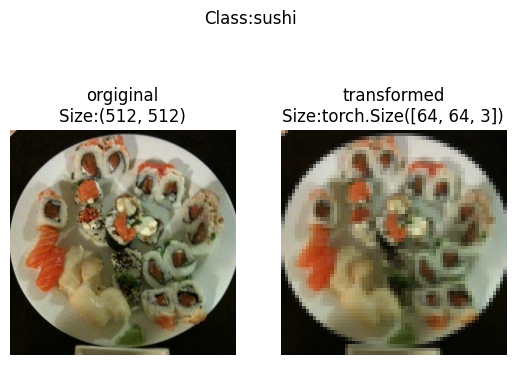

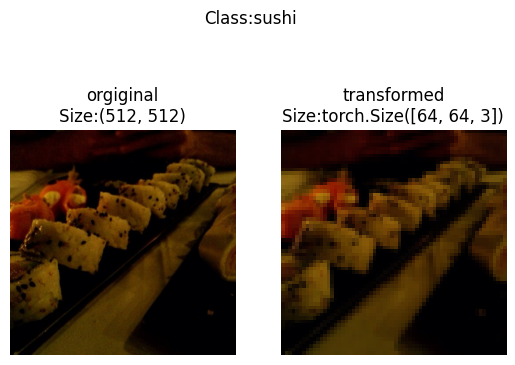

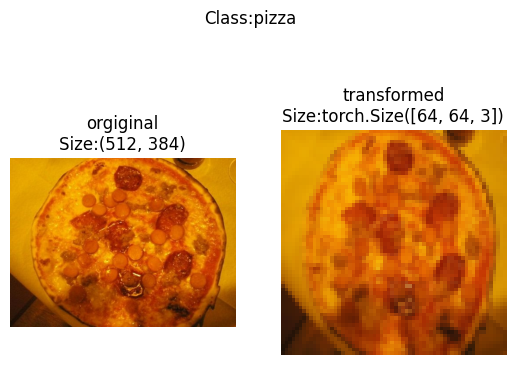

In [75]:
def plot_transformed_image(image_path,transform,n=3,seed=42):
  """ select the random images from the path of images and load /transform
  them then plots the original vs transformed version.
  """
  if seed:
    random.seed(seed)
    random_image=random.sample(image_path,k=n)
  for image_path in random_image:
    transformed_image=transform(Image.open(image_path))
    with Image.open(image_path) as f:
      fig,ax=plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"orgiginal\nSize:{f.size}")
      ax[0].axis(False)

      #Transform and plot the target image
      transformed_image=transform(f).permute(1,2,0) # we just  chaningthe order chw ->hwc
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"transformed\nSize:{transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class:{image_path.parent.stem}",fontsize=12)
plot_transformed_image(image_path=image_path_list,
                       transform=data_transform,
                       n=3,
                       seed=42)
